# Classificação de Câncer de Mama — Wisconsin Breast Cancer Dataset

Este notebook realiza uma análise completa do dataset **Wisconsin Breast Cancer**, com o objetivo de classificar tumores como **benignos** ou **malignos** a partir de características extraídas de imagens de células.

O pipeline inclui:
1. **Importação e limpeza** dos dados
2. **Análise exploratória** (distribuições, correlações, visualizações)
3. **Pré-processamento** (encoding, escalonamento, divisão treino/teste)
4. **Treinamento** de 3 modelos: Regressão Logística, Random Forest e XGBoost
5. **Avaliação** com matrizes de confusão e acurácia
6. **Interpretabilidade** com SHAP values

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para todo o pipeline:

- **pandas / numpy**: manipulação e operações numéricas sobre os dados.
- **matplotlib / seaborn**: visualização de dados.
- **sklearn**: pré-processamento (`StandardScaler`, `LabelEncoder`), divisão treino/teste (`train_test_split`) e métricas de avaliação (`classification_report`, `confusion_matrix`, `accuracy_score`).
- **LogisticRegression / RandomForestClassifier / XGBClassifier**: os três modelos de classificação que serão comparados.
- **shap**: interpretabilidade dos modelos via SHAP values.

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e Limpeza dos Dados

Carregamos o arquivo `data.csv` e realizamos duas operações de limpeza:

1. **Remoção da coluna `id`**: é um identificador único sem valor preditivo.
2. **Remoção de colunas totalmente nulas**: elimina colunas que não contêm nenhum dado (ex: coluna extra gerada por vírgula final no CSV).

Em seguida, exibimos as 5 primeiras linhas e verificamos se existem valores nulos restantes no dataset.

In [17]:
import os

os.makedirs('../outputs/reports', exist_ok=True)

df = pd.read_csv('../data/data.csv')

df = df.drop(['id'], axis=1)
df = df.dropna(axis=1, how='all')

display(df.head())
print("\nValores nulos no dataset:\n", df.isnull().sum().max(), "nulos encontrados.")

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Valores nulos no dataset:
 0 nulos encontrados.


## 3. Configuração Visual dos Gráficos

Definimos a paleta de cores e os parâmetros visuais globais:

- **Azul (`#4C72B0`)** para tumores **benignos** e **vermelho (`#C0392B`)** para **malignos**, garantindo distinção visual clara.
- Estilo `whitegrid` do seaborn para gráficos limpos.
- Removemos as bordas superior e direita dos eixos para um visual mais moderno.

Essa padronização garante consistência em todos os gráficos do notebook.

In [18]:
PALETTE   = {'Benigno': '#4C72B0', 'Maligno': '#C0392B'}
COLOR_B   = '#4C72B0'
COLOR_M   = '#C0392B'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.dpi':         110,
})


## 4. Distribuição dos Diagnósticos

Criamos um **gráfico de barras** mostrando a quantidade e o percentual de cada classe (`Benigno` vs `Maligno`).

Esse gráfico permite avaliar o **balanceamento do dataset**. Verificar se as classes estão equilibradas é fundamental, pois um desbalanceamento severo pode prejudicar o desempenho dos modelos, especialmente em relação à classe minoritária.

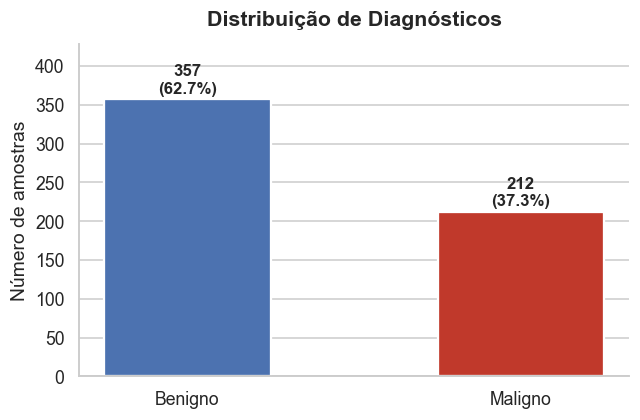

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['diagnosis'].value_counts().sort_index()
labels = ['Benigno', 'Maligno']
colors = [COLOR_B, COLOR_M]

bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4,
            f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribuição de Diagnósticos', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Número de amostras')
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()


## 5. Matriz de Correlação — Features Mean

Calculamos a **matriz de correlação de Pearson** entre as features do tipo `_mean` e a visualizamos com um **heatmap** triangular.

- Correlações **próximas de 1 (vermelho)** indicam forte relação positiva entre variáveis.
- Correlações **próximas de -1 (azul)** indicam forte relação negativa.

Identificar **alta colinearidade** entre features é importante: variáveis muito correlacionadas podem introduzir redundância, afetando a estabilidade e a interpretabilidade de alguns modelos.

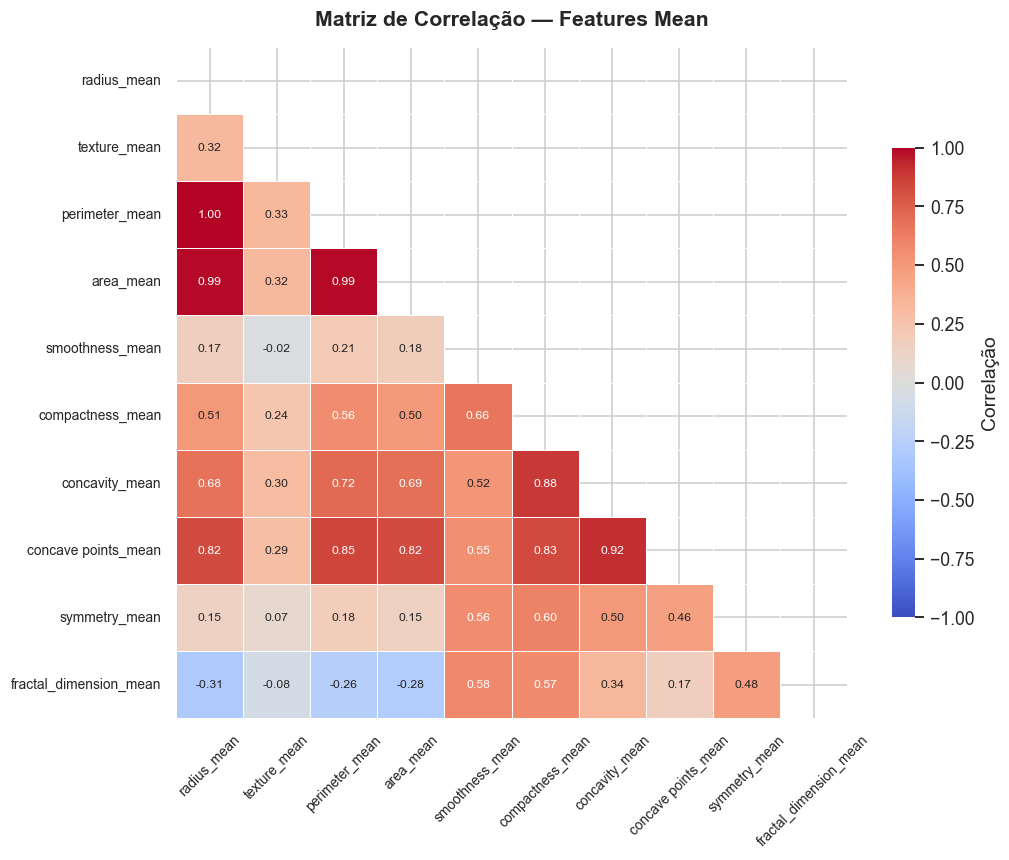

In [20]:
mean_cols   = [col for col in df.columns if '_mean' in col or 'mean_' in col]
corr_matrix = df[mean_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.4,
    square=True,
    cbar_kws={'shrink': 0.7, 'label': 'Correlação'},
    ax=ax
)

ax.set_title('Matriz de Correlação — Features Mean', fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()


## 6. Boxplots Comparativos por Diagnóstico

Utilizamos **boxplots** para as 6 primeiras features `_mean`, comparando a distribuição entre tumores benignos e malignos.

Os boxplots permitem visualizar de forma compacta:
- A **mediana** de cada feature por classe (linha branca central).
- O **intervalo interquartil (IQR)** — onde estão 50% dos dados.
- Os **whiskers** — alcance dos valores sem considerar outliers.
- Os **outliers** individuais (pontos fora dos whiskers).

> **Observação:** features como `radius`, `perimeter` e `area` mostram separação muito clara entre as classes — indicativo de alto poder discriminativo para o modelo.


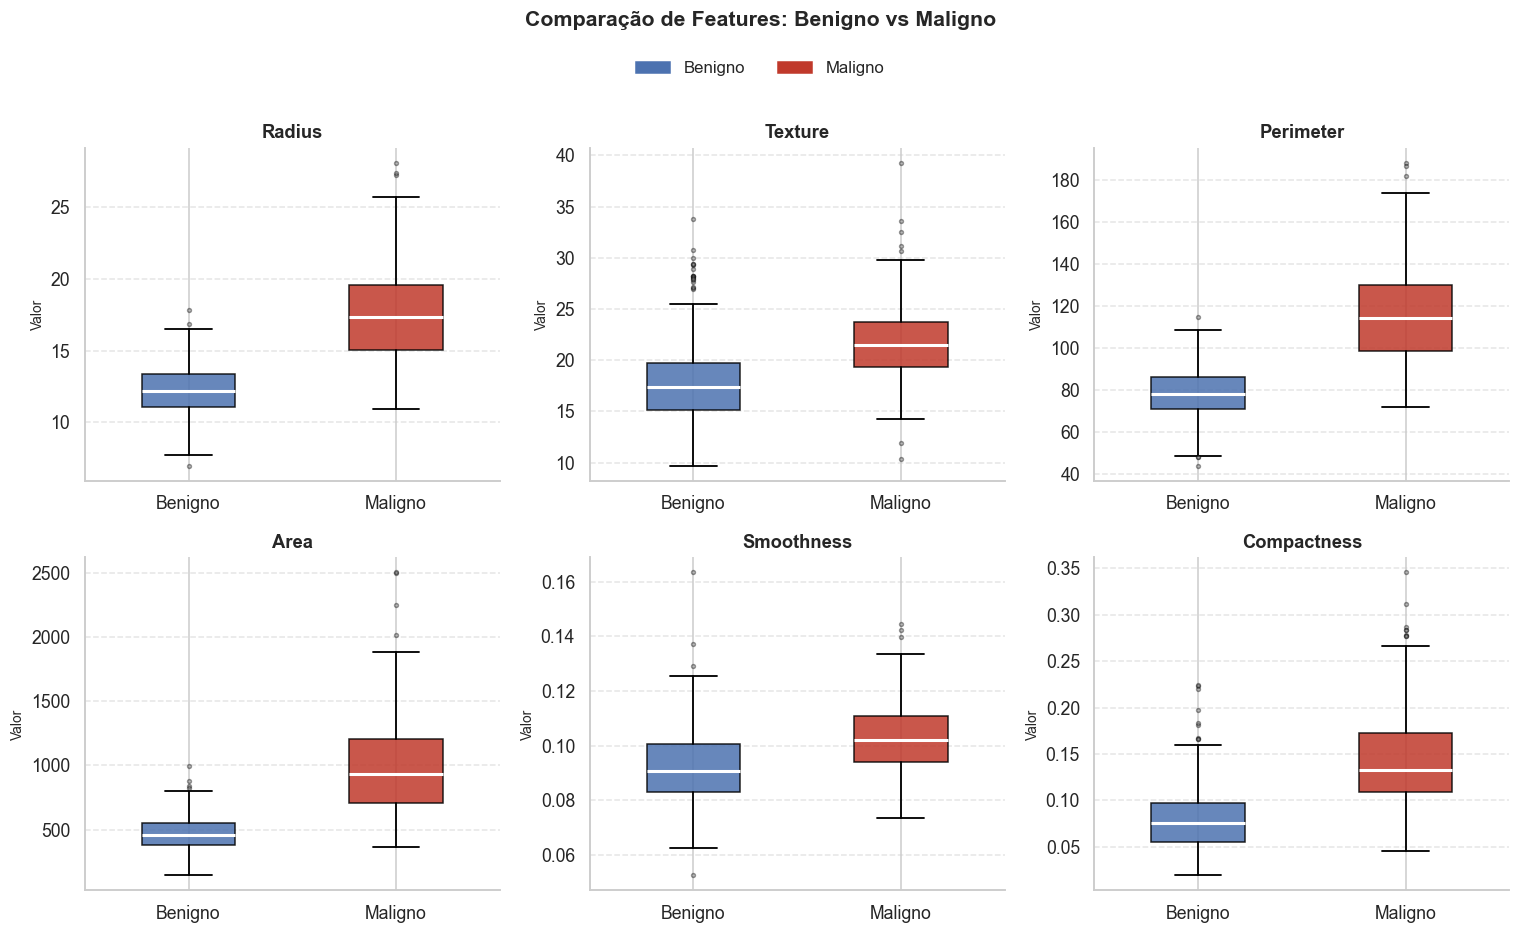

In [21]:
df_plot = df.copy()
df_plot['Tipo'] = df_plot['diagnosis'].map({'B': 'Benigno', 'M': 'Maligno'})

features = [col for col in df.columns if '_mean' in col or 'mean_' in col][:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]

    benignos  = df_plot.loc[df_plot['Tipo'] == 'Benigno',  col]
    malignos  = df_plot.loc[df_plot['Tipo'] == 'Maligno',  col]

    bp = ax.boxplot(
        [benignos, malignos],
        labels=['Benigno', 'Maligno'],
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2.5,
                        markerfacecolor='#888', alpha=0.4, linestyle='none'),
    )

    for patch, color in zip(bp['boxes'], [COLOR_B, COLOR_M]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    titulo = col.replace('_mean', '').replace('mean_', '').replace('_', ' ').title()
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
legend_handles = [Patch(color=COLOR_B, label='Benigno'),
                  Patch(color=COLOR_M, label='Maligno')]
fig.legend(handles=legend_handles, loc='upper center', ncol=2,
           frameon=False, fontsize=11, bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Comparação de Features: Benigno vs Maligno',
             fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

## 7. Violin Plot — Distribuição e Densidade

O **violin plot** combina um boxplot com uma estimativa de densidade (KDE), mostrando não só os quartis mas também a **forma completa da distribuição** de cada feature.

Com `split=True`, cada metade do violino representa uma classe, facilitando a comparação direta:
- Metade **azul** → Benigno
- Metade **vermelha** → Maligno
- Linhas internas → quartis (Q1, mediana, Q3)

> **Diferença em relação ao boxplot:** o violin revela se a distribuição é **unimodal, bimodal ou assimétrica** — informação que o boxplot omite. Features como `area_mean` e `perimeter_mean` mostram distribuições com cauda longa para malignos.


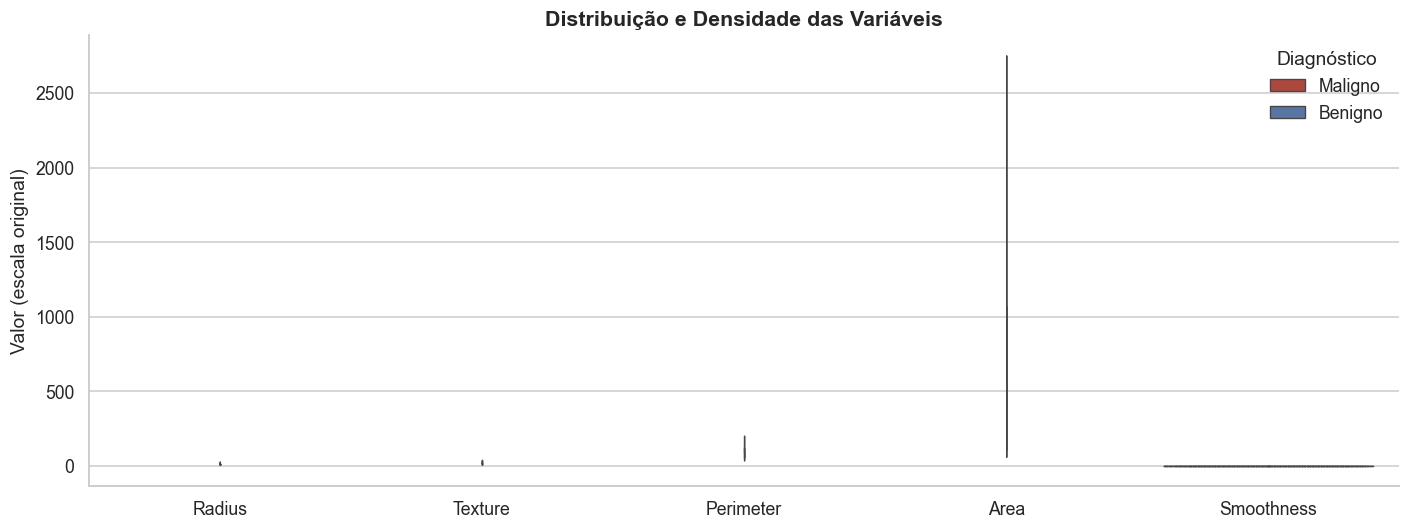

In [22]:
features_mean = [col for col in df.columns if '_mean' in col or 'mean_' in col][:5]

df_plot = df.copy()
df_plot['Tipo'] = df_plot['diagnosis'].map({'B': 'Benigno', 'M': 'Maligno'})

df_melted = df_plot.melt(
    id_vars=['Tipo'],
    value_vars=features_mean,
    var_name='Feature', value_name='Valor'
)

df_melted['Feature'] = (df_melted['Feature']
                        .str.replace('_mean', '', regex=False)
                        .str.replace('mean_', '', regex=False)
                        .str.replace('_', ' ')
                        .str.title())

fig, ax = plt.subplots(figsize=(13, 5))

sns.violinplot(
    data=df_melted,
    x='Feature', y='Valor', hue='Tipo',
    palette=PALETTE,
    split=True,
    inner='quartile',
    linewidth=0.9,
    ax=ax
)

ax.set_title('Distribuição e Densidade das Variáveis', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Valor (escala original)')
ax.legend(title='Diagnóstico', frameon=False)

plt.tight_layout()
plt.show()


## 8. Joint Plot — Radius Mean vs Texture Mean

Criamos um **joint plot** combinando um scatter plot e histogramas marginais para as features `radius_mean` e `texture_mean`, coloridos por diagnóstico.

Essa visualização permite avaliar:
- A **relação bivariada** entre duas features.
- A **separabilidade visual** das classes no espaço bidimensional.
- Se existe algum **padrão** ou **cluster** natural nos dados que ajude na classificação.

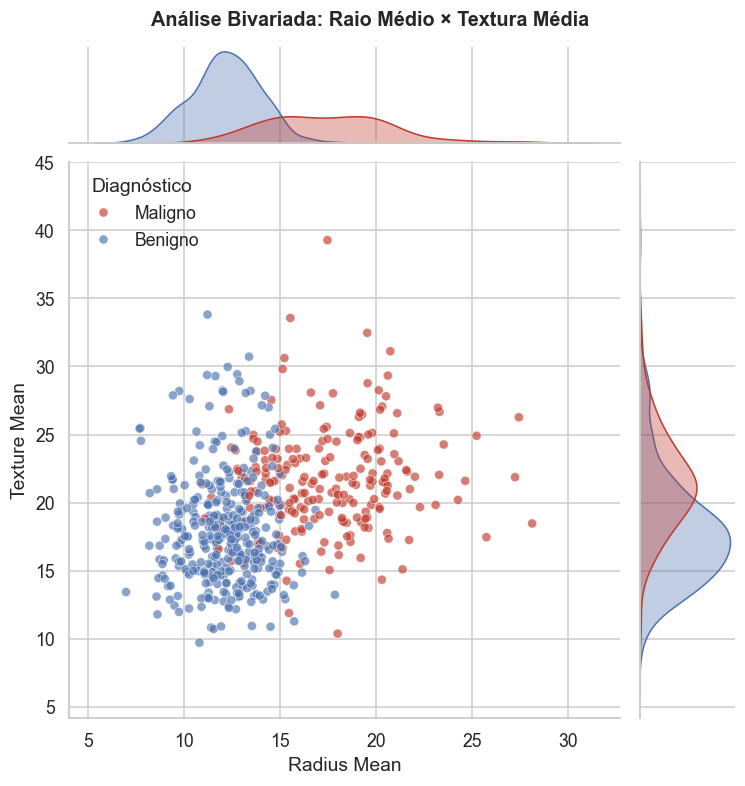

In [23]:
radius_col  = next(c for c in df.columns if 'radius'  in c and ('mean' in c))
texture_col = next(c for c in df.columns if 'texture' in c and ('mean' in c))

g = sns.jointplot(
    data=df_plot,
    x=radius_col, y=texture_col,
    hue='Tipo',
    palette=PALETTE,
    height=7,
    alpha=0.65,
    marginal_kws=dict(fill=True, alpha=0.35)
)

g.ax_joint.set_xlabel(radius_col.replace('_', ' ').title())
g.ax_joint.set_ylabel(texture_col.replace('_', ' ').title())
g.figure.suptitle('Análise Bivariada: Raio Médio × Textura Média',
                   y=1.02, fontsize=13, fontweight='bold')

g.ax_joint.legend(title='Diagnóstico', frameon=False, loc='upper left')

plt.show()


## 9. Pré-processamento dos Dados

Preparamos os dados para o treinamento dos modelos:

1. **Label Encoding**: convertemos a coluna `diagnosis` de categórica (`B`/`M`) para numérica (`0`/`1`).
2. **Separação X/y**: separamos as features (X) da variável-alvo (y).
3. **Train/Test Split**: dividimos em 80% treino e 20% teste, com `stratify=y` para manter a proporção de classes em ambos os conjuntos.
4. **Standard Scaler**: padronizamos as features para média 0 e desvio padrão 1. Isso é essencial para modelos como Regressão Logística, que são sensíveis à escala das variáveis.

In [24]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Tamanho do treino: {X_train_scaled.shape[0]} amostras")
print(f"Tamanho do teste: {X_test_scaled.shape[0]} amostras")

Tamanho do treino: 455 amostras
Tamanho do teste: 114 amostras


## 10. Treinamento dos Modelos

Treinamos **3 modelos de classificação** nos dados de treino escalonados:

| Modelo | Descrição |
|---|---|
| **Regressão Logística** | Modelo linear simples, eficiente para problemas binários. |
| **Random Forest** | Ensemble de árvores de decisão, robusto e menos propenso a overfitting. |
| **XGBoost** | Gradient Boosting otimizado, geralmente o melhor desempenho em dados tabulares. |

Após o treinamento, geramos as **previsões** de cada modelo sobre o conjunto de teste.

In [25]:
modelos = {
    "Regressão Logística": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

previsoes = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    previsoes[nome] = modelo.predict(X_test_scaled)
    print(f"[{nome}] treinado com sucesso!")

[Regressão Logística] treinado com sucesso!
[Random Forest] treinado com sucesso!
[XGBoost] treinado com sucesso!


## 11. Matrizes de Confusão e Acurácia

Para cada modelo, plotamos a **matriz de confusão** e exibimos a **acurácia** no título.

A matriz de confusão mostra:
- **Verdadeiros positivos / negativos**: previsões corretas.
- **Falsos positivos / negativos**: erros do modelo.

No contexto médico, **falsos negativos** (prever benigno quando é maligno) são especialmente críticos, pois podem atrasar o tratamento. Comparar os erros de cada modelo ajuda a escolher o mais adequado para o cenário clínico.

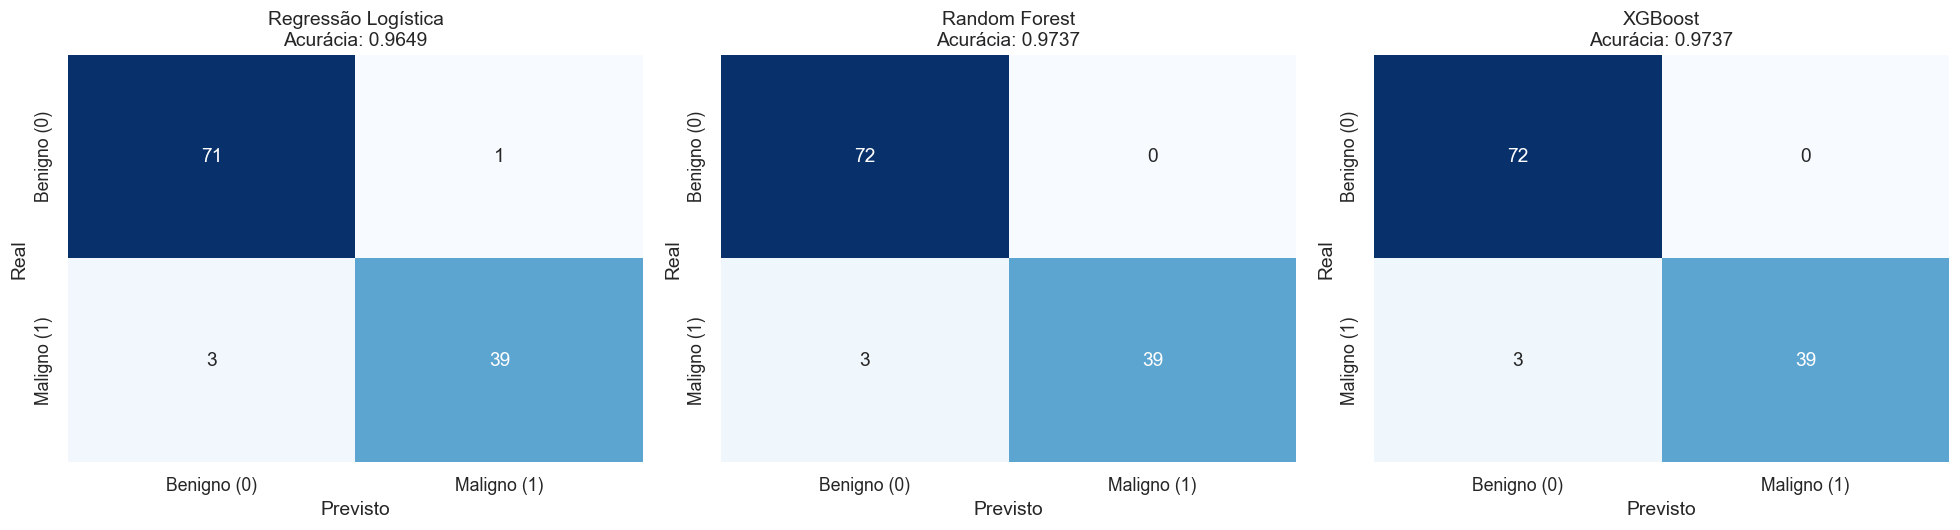


Relatório de Classificação (XGBoost):
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, y_pred) in zip(axes, previsoes.items()):
    acc = accuracy_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    
    ax.set_title(f'{nome}\nAcurácia: {acc:.4f}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['Benigno (0)', 'Maligno (1)'])
    ax.set_yticklabels(['Benigno (0)', 'Maligno (1)'])

plt.tight_layout()
plt.show()

print("\nRelatório de Classificação (XGBoost):")
print(classification_report(y_test, previsoes["XGBoost"], target_names=['Benigno', 'Maligno']))

In [27]:
# Salva relatórios de todos os modelos
with open('../outputs/reports/classification_report.txt', 'w', encoding='utf-8') as f:
    for nome, y_pred in previsoes.items():
        f.write(f"{'='*50}\n")
        f.write(f"Modelo: {nome}\n")
        f.write(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n\n")
        f.write(classification_report(y_test, y_pred, target_names=['Benigno', 'Maligno']))
        f.write('\n')

print("Relatório salvo em outputs/reports/classification_report.txt")

Relatório salvo em outputs/reports/classification_report.txt


## 12. Interpretabilidade com SHAP Values

Utilizamos **SHAP (SHapley Additive exPlanations)** para interpretar as previsões do modelo XGBoost.

O **summary plot (dot)** mostra:
- Cada ponto é uma amostra do conjunto de teste.
- A **posição no eixo X** indica o impacto da feature na predição (positivo → empurra para Maligno).
- A **cor** indica o valor original da feature: vermelho = alto, azul = baixo.
- As features estão ordenadas por **importância global** (de cima para baixo).

> **Interpretação:** features com pontos vermelhos à direita (ex: `concave points_worst`) indicam que valores altos dessa feature aumentam a probabilidade de o tumor ser classificado como maligno — consistente com a biologia tumoral.


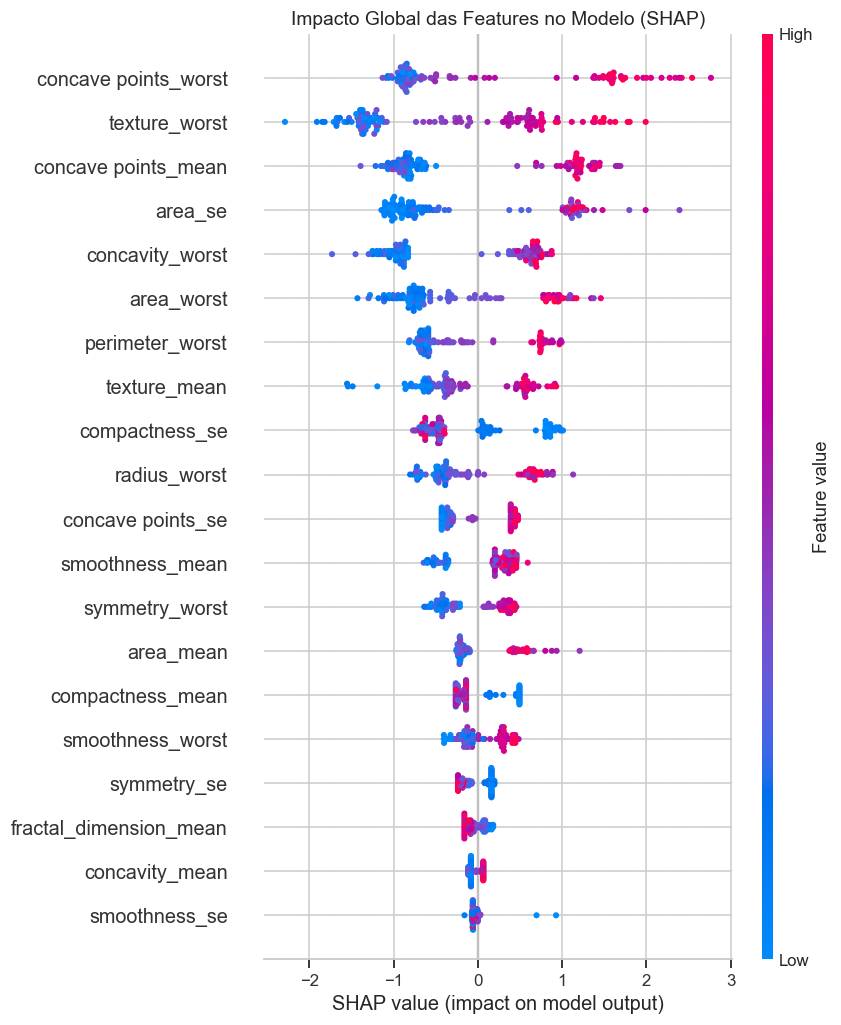

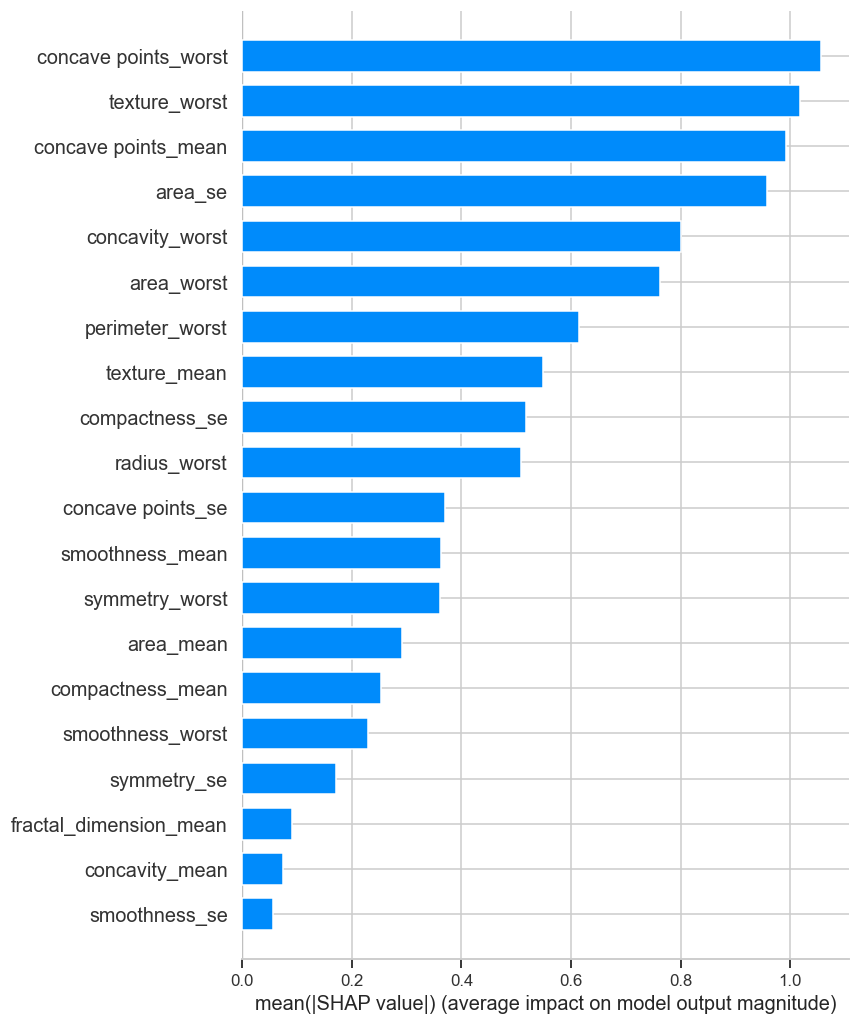

In [28]:
shap.initjs()

explainer = shap.TreeExplainer(modelos["XGBoost"])

shap_values = explainer.shap_values(X_test_scaled)

plt.title("Impacto Global das Features no Modelo (SHAP)")
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")

shap.summary_plot(shap_values, X_test_scaled, plot_type="bar") 